# RQ4 – GEG vs Baseline per Classificatore: Fairness e Performance

**Research Question 4**: Does GEG improve fairness compared to the model-specific baseline (no debiasing) without significantly degrading predictive performance, across different classifiers?

- **Datasets**: cmc, crime, drug, law, obesity, park, wine  
- **Models**: `rf` (Random Forest), `xgb` (XGBoost)  
- **GEG constraints**: `cp` (Calibrated Parity), `dp` (Demographic Parity), `eo` (Equal Opportunity)  
- **Baseline**: model-specific, no debiasing (`results_models/`)  
- **Fairness metrics**: Statistical Parity (SP), Equal Opportunity (EO), Average Odds (AO) – weighted cross-class, absolute values  
- **Performance metrics**: Accuracy, Precision, Recall, F1-score  
- **Statistical test**: Wilcoxon signed-rank + Vargha-Delaney A (intra-model: GEG-RF vs Baseline-RF, etc.)

## 1. Importazione delle Librerie

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy.stats import wilcoxon

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.4f}".format)

EXPERIMENTS = Path(".")  # notebook lives inside experiments/
IMGS = EXPERIMENTS / "imgs"
IMGS.mkdir(exist_ok=True)

DATASETS    = ["cmc", "crime", "drug", "law", "obesity", "park", "wine"]
MODELS      = ["rf", "xgb"]
CONSTRAINTS = ["cp", "dp", "eo"]

FAIRNESS_METRICS   = ["wc_statistical_parity", "wc_equal_opportunity", "wc_average_odds"]
PERFORMANCE_METRICS = ["accuracy", "precision", "recall", "f1_score"]

METRIC_LABELS = {
    "wc_statistical_parity": "Statistical Parity",
    "wc_equal_opportunity":  "Equal Opportunity",
    "wc_average_odds":       "Average Odds",
    "accuracy":  "Accuracy",
    "precision": "Precision",
    "recall":    "Recall",
    "f1_score":  "F1-score",
}

METHOD_LABELS = {
    "Baseline": "Baseline",
    "DEMV": "DEMV",
    "Blackbox": "Blackbox",
    "GEG-DP":   "GEG-SP",
    "GEG-EO":   "GEG-EO",
    "GEG-CP":   "GEG-CP",
}
METHODS_ORDER = ["Baseline", "DEMV", "Blackbox", "GEG-CP", "GEG-SP", "GEG-EO"]

MODEL_LABELS = {"rf": "Random Forest", "xgb": "XGBoost"}

PALETTE = sns.color_palette(n_colors=len(METHOD_LABELS))

print("Libraries loaded.")

Libraries loaded.


## 2. Caricamento e Preparazione dei Dati

In [3]:
def load_baseline_models(datasets=DATASETS, models=MODELS):
    """Load baseline (no-debiasing) results for each dataset × model."""
    dfs = []
    for ds in datasets:
        for model in models:
            f = EXPERIMENTS / "results_models" / f"{ds}_{model}_results.csv"
            if not f.exists():
                print(f"[WARN] missing: {f}")
                continue
            df = pd.read_csv(f)
            df["dataset"] = ds
            df["model"]   = model
            df["method"]  = "Baseline"
            dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

def load_demv_rq4(datasets=DATASETS, models=MODELS):
    """Load DEMV RQ4 results for each dataset × model."""
    dfs = []
    for ds in datasets:
        for model in models:
            f = EXPERIMENTS / "results_demv" / f"{ds}_{model}_results.csv"
            if not f.exists():
                print(f"[WARN] missing: {f}")
                continue
            df = pd.read_csv(f)
            df["dataset"] = ds
            df["model"]   = model
            df["method"]  = "DEMV"
            dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

def load_blackbox_rq4(datasets=DATASETS, models=MODELS):
    """Load Black-box RQ4 results for each dataset × model."""
    dfs = []
    for ds in datasets:
        for model in models:
            f = EXPERIMENTS / "results_blackbox" / f"{ds}_{model}_results.csv"
            if not f.exists():
                print(f"[WARN] missing: {f}")
                continue
            df = pd.read_csv(f)
            df["dataset"] = ds
            df["model"]   = model
            df["method"]  = "Blackbox"
            dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

def load_geg_rq4(datasets=DATASETS, constraints=CONSTRAINTS, models=MODELS):
    """Load GEG RQ4 results for each dataset × constraint × model."""
    dfs = []
    for ds in datasets:
        for c in constraints:
            for model in models:
                f = EXPERIMENTS / "results_geg_rq4" / f"{ds}_geg_{c}_{model}_results.csv"
                if not f.exists():
                    print(f"[WARN] missing: {f}")
                    continue
                df = pd.read_csv(f)
                df["dataset"]    = ds
                df["model"]      = model
                df["constraint"] = c
                df["method"]     = f"GEG-{c.upper()}"
                dfs.append(df)
    return pd.concat(dfs, ignore_index=True)


baseline = load_baseline_models()
demv     = load_demv_rq4()
blackbox = load_blackbox_rq4()
geg      = load_geg_rq4()

df_all = pd.concat([baseline, demv, blackbox, geg], ignore_index=True)

# Absolute values for fairness metrics
for m in FAIRNESS_METRICS:
    df_all[m] = df_all[m].abs()

df_all["method"] = df_all["method"].map(METHOD_LABELS)

expected_rows = len(DATASETS) * len(MODELS) * len(METHODS_ORDER) * 10
print(f"Loaded {len(df_all)} rows (expected ~{expected_rows})")
print(f"Methods:  {sorted(df_all['method'].unique())}")
print(f"Models:   {sorted(df_all['model'].unique())}")
print(f"Datasets: {sorted(df_all['dataset'].unique())}")
df_all.head()

Loaded 840 rows (expected ~840)
Methods:  ['Baseline', 'Blackbox', 'DEMV', 'GEG-CP', 'GEG-EO', 'GEG-SP']
Models:   ['rf', 'xgb']
Datasets: ['cmc', 'crime', 'drug', 'law', 'obesity', 'park', 'wine']


,fold,accuracy,precision,recall,f1_score,statistical_parity,equal_opportunity,average_odds,wc_statistical_parity,wc_equal_opportunity,wc_average_odds,constraint,dataset,model,method
0,1,0.9797,0.9760,0.9808,0.9782,0.0289,-0.1429,-0.0766,0.0289,0.1429,0.0766,rf,cmc,rf,Baseline
1,2,0.9797,0.9797,0.9760,0.9778,0.1967,0.0769,0.0333,0.1967,0.0769,0.0333,rf,cmc,rf,Baseline
2,3,0.9797,0.9838,0.9714,0.9771,0.1452,-0.0994,-0.0497,0.1452,0.0994,0.0497,rf,cmc,rf,Baseline
3,4,0.9728,0.9762,0.9712,0.9729,0.1392,0.0645,0.0323,0.1392,0.0645,0.0323,rf,cmc,rf,Baseline
4,5,0.9728,0.9649,0.9622,0.9635,0.1293,-0.2857,-0.1520,0.1293,0.2857,0.1520,rf,cmc,rf,Baseline


## 3. Sommari: Fairness e Performance

Media ± deviazione standard sui 10 fold per ciascuna combinazione (dataset, model, method).

In [4]:
fairness_summary = (
    df_all.groupby(["dataset", "model", "method"])[FAIRNESS_METRICS]
    .agg(["mean", "std"])
    .reset_index()
)
fairness_summary.columns = ["_".join(c).strip("_") for c in fairness_summary.columns]
fairness_summary["method"] = pd.Categorical(
    fairness_summary["method"], categories=METHODS_ORDER, ordered=True
)
fairness_summary = fairness_summary.sort_values(["dataset", "model", "method"])

perf_summary = (
    df_all.groupby(["dataset", "model", "method"])[PERFORMANCE_METRICS]
    .agg(["mean", "std"])
    .reset_index()
)
perf_summary.columns = ["_".join(c).strip("_") for c in perf_summary.columns]
perf_summary["method"] = pd.Categorical(
    perf_summary["method"], categories=METHODS_ORDER, ordered=True
)
perf_summary = perf_summary.sort_values(["dataset", "model", "method"])

print(f"fairness_summary: {fairness_summary.shape}")
fairness_summary.head(12)

fairness_summary: (84, 9)


,dataset,model,method,wc_statistical_parity_mean,wc_statistical_parity_std,wc_equal_opportunity_mean,wc_equal_opportunity_std,wc_average_odds_mean,wc_average_odds_std
0,cmc,rf,Baseline,0.1317,0.0767,0.1313,0.0699,0.0638,0.0355
2,cmc,rf,DEMV,0.1233,0.0884,0.0882,0.0409,0.0441,0.0210
1,cmc,rf,Blackbox,0.1022,0.0740,0.3317,0.1805,0.2038,0.1094
3,cmc,rf,GEG-CP,0.1376,0.0549,0.1728,0.0910,0.0926,0.0478
5,cmc,rf,GEG-SP,0.0691,0.0361,0.1926,0.0431,0.1068,0.0362
4,cmc,rf,GEG-EO,0.1528,0.0803,0.1042,0.0487,0.0523,0.0243
6,cmc,xgb,Baseline,0.1477,0.0819,0.0145,0.0165,0.0067,0.0075
8,cmc,xgb,DEMV,0.1477,0.0819,0.0145,0.0165,0.0067,0.0075
7,cmc,xgb,Blackbox,0.1379,0.0787,0.0616,0.0905,0.0395,0.0564
9,cmc,xgb,GEG-CP,0.1275,0.0873,0.1435,0.0799,0.0846,0.0349


## 4. Test Statistici: Wilcoxon + Vargha-Delaney A

Confronto **intra-model**: GEG-{constraint} vs Baseline per ciascuna combinazione (dataset, model).

- **Fairness** (lower is better): `alternative="greater"` — test che il baseline abbia valori più alti
- **Performance** (higher is better): `alternative="less"` — test che il baseline abbia valori più bassi
- **Bold** = $p < 0.05$ + large effect ($|A - 0.5| \geq 0.21$)
- **Italic** = $p < 0.05$ only

In [5]:
def vargha_delaney_a(x, y):
    """Vargha-Delaney A = P(X > Y) + 0.5*P(X == Y).
    |A - 0.5| >= 0.21 → large effect.
    """
    n = len(x) * len(y)
    more = sum(xi > yj for xi in x for yj in y)
    tie  = sum(xi == yj for xi in x for yj in y)
    return (more + 0.5 * tie) / n


_ALL_METRICS = [
    "wc_statistical_parity", "wc_equal_opportunity", "wc_average_odds",
    "accuracy", "precision", "recall", "f1_score",
]

stat_records = []
baseline_df  = df_all[df_all["method"] == "Baseline"]
geg_methods  = [m for m in METHODS_ORDER if m != "Baseline"]

for ds in DATASETS:
    for model in MODELS:
        b_rows = baseline_df[
            (baseline_df["dataset"] == ds) & (baseline_df["model"] == model)
        ].sort_values("fold")
        if len(b_rows) == 0:
            continue
        for geg_method in geg_methods:
            g_rows = df_all[
                (df_all["dataset"] == ds) &
                (df_all["model"]   == model) &
                (df_all["method"]  == geg_method)
            ].sort_values("fold")
            if len(g_rows) == 0:
                continue
            for metric in _ALL_METRICS:
                b_vals = b_rows[metric].values
                g_vals = g_rows[metric].values
                if len(b_vals) < 2 or len(b_vals) != len(g_vals):
                    continue
                diff = g_vals - b_vals
                if np.all(diff == 0):
                    p_val = 1.0
                else:
                    try:
                        if metric in FAIRNESS_METRICS:
                            _, p_val = wilcoxon(b_vals, g_vals, alternative="greater")
                        else:
                            _, p_val = wilcoxon(b_vals, g_vals, alternative="less")
                    except Exception:
                        p_val = 1.0
                a = vargha_delaney_a(g_vals, b_vals)
                stat_records.append({
                    "dataset":      ds,
                    "model":        model,
                    "method":       geg_method,
                    "metric":       metric,
                    "p_value":      p_val,
                    "vda":          a,
                    "significant":  p_val < 0.05,
                    "large_effect": abs(a - 0.5) >= 0.21,
                })

stat_df = pd.DataFrame(stat_records)
expected_stat = len(DATASETS) * len(MODELS) * len(geg_methods) * len(_ALL_METRICS)
print(f"Computed {len(stat_df)} comparisons (expected ~{expected_stat})")
stat_df.head(14)

Computed 490 comparisons (expected ~490)


,dataset,model,method,metric,p_value,vda,significant,large_effect
0,cmc,rf,DEMV,wc_statistical_parity,0.3340,0.5150,False,False
1,cmc,rf,DEMV,wc_equal_opportunity,0.0391,0.3400,True,False
2,cmc,rf,DEMV,wc_average_odds,0.0488,0.3450,True,False
3,cmc,rf,DEMV,accuracy,0.0938,0.6000,False,False
4,cmc,rf,DEMV,precision,0.1250,0.6350,False,False
5,cmc,rf,DEMV,recall,0.1914,0.5500,False,False
6,cmc,rf,DEMV,f1_score,0.1250,0.5750,False,False
7,cmc,rf,Blackbox,wc_statistical_parity,0.2783,0.3900,False,False
8,cmc,rf,Blackbox,wc_equal_opportunity,0.9932,0.8650,False,True
9,cmc,rf,Blackbox,wc_average_odds,0.9990,0.9000,False,True


## 5. Tabelle Comparative Fairness + Performance

Una tabella per ciascun classificatore (RF, SVM, XGB).  
Ogni riga corrisponde a una combinazione (Dataset, Method).  
**Bold** = $p < 0.05$ + large effect; *Italic* = $p < 0.05$ only.

In [6]:
def fmt(mean_col, std_col, df):
    return df[mean_col].map("{:.3f}".format) + r" $\pm$ " + df[std_col].map("{:.3f}".format)


def fmt_stat(mean_col, std_col, metric_name, df, stat_df_model):
    """Format cells: \\textbf{} if significant + large effect, \\textit{} if significant only.
    Baseline rows are left unformatted.
    """
    base_str = fmt(mean_col, std_col, df)
    result = []
    for idx, row in df.iterrows():
        s = base_str.loc[idx]
        if row["method"] == "Baseline":
            result.append(s)
            continue
        match = stat_df_model[
            (stat_df_model["dataset"] == row["dataset"]) &
            (stat_df_model["method"]  == row["method"]) &
            (stat_df_model["metric"]  == metric_name)
        ]
        if match.empty:
            result.append(s)
            continue
        sig   = bool(match.iloc[0]["significant"])
        large = bool(match.iloc[0]["large_effect"])
        if sig and large:
            result.append(r"\textbf{" + s + "}")
        elif sig:
            result.append(r"\textit{" + s + "}")
        else:
            result.append(s)
    return pd.Series(result, index=df.index)


combined = fairness_summary.merge(perf_summary, on=["dataset", "model", "method"])

tables = {}
for model in MODELS:
    comb_m = combined[combined["model"] == model].copy()
    stat_m = stat_df[stat_df["model"] == model]
    table = pd.DataFrame({
        "Dataset":   comb_m["dataset"],
        "Method":    comb_m["method"],
        "SP":        fmt_stat("wc_statistical_parity_mean", "wc_statistical_parity_std", "wc_statistical_parity", comb_m, stat_m),
        "EO":        fmt_stat("wc_equal_opportunity_mean",  "wc_equal_opportunity_std",  "wc_equal_opportunity",  comb_m, stat_m),
        "AO":        fmt_stat("wc_average_odds_mean",       "wc_average_odds_std",       "wc_average_odds",       comb_m, stat_m),
        "Accuracy":  fmt_stat("accuracy_mean",  "accuracy_std",  "accuracy",  comb_m, stat_m),
        "Precision": fmt_stat("precision_mean", "precision_std", "precision", comb_m, stat_m),
        "Recall":    fmt_stat("recall_mean",    "recall_std",    "recall",    comb_m, stat_m),
        "F1-score":  fmt_stat("f1_score_mean",  "f1_score_std",  "f1_score",  comb_m, stat_m),
    })
    tables[model] = table

print("Tables built for:", list(tables.keys()))

Tables built for: ['rf', 'xgb']


In [7]:
print("=== RQ4 — Random Forest ===")
print("    Bold   = significant (p<0.05) + large effect (|A−0.5|≥0.21)")
print("    Italic = significant (p<0.05) only\n")
display(tables["rf"].set_index(["Dataset", "Method"]))

=== RQ4 — Random Forest ===
    Bold   = significant (p<0.05) + large effect (|A−0.5|≥0.21)
    Italic = significant (p<0.05) only



SP                          EO  \
Dataset Method                                                             
cmc     Baseline           0.132 $\pm$ 0.077           0.131 $\pm$ 0.070   
        DEMV               0.123 $\pm$ 0.088  \textit{0.088 $\pm$ 0.041}   
        Blackbox           0.102 $\pm$ 0.074           0.332 $\pm$ 0.181   
        GEG-CP             0.138 $\pm$ 0.055           0.173 $\pm$ 0.091   
        GEG-SP    \textbf{0.069 $\pm$ 0.036}           0.193 $\pm$ 0.043   
        GEG-EO             0.153 $\pm$ 0.080           0.104 $\pm$ 0.049   
crime   Baseline           0.422 $\pm$ 0.055           0.491 $\pm$ 0.226   
        DEMV      \textbf{0.346 $\pm$ 0.039}           0.456 $\pm$ 0.192   
        Blackbox           0.411 $\pm$ 0.070           0.652 $\pm$ 0.173   
        GEG-CP    \textbf{0.180 $\pm$ 0.048}           0.412 $\pm$ 0.095   
        GEG-SP    \textbf{0.148 $\pm$ 0.064}           0.412 $\pm$ 0.132   
        GEG-EO             0.423 $\pm$ 0.050           0.514 $\pm$ 0.191   
drug    Baseline           0.160 $\pm$ 0.102           0.380 $\pm$ 0.105   
        DEMV      \textbf{0.088 $\pm$ 0.055}           0.322 $\pm$ 0.111   
        Blackbox           0.357 $\pm$ 0.135           0.647 $\pm$ 0.110   
        GEG-CP    \textit{0.113 $\pm$ 0.091}  \textbf{0.209 $\pm$ 0.072}   
        GEG-SP    \textit{0.089 $\pm$ 0.064}           0.336 $\pm$ 0.049   
        GEG-EO             0.161 $\pm$ 0.109           0.344 $\pm$ 0.080   
law     Baseline           0.162 $\pm$ 0.024           0.151 $\pm$ 0.035   
        DEMV      \textbf{0.143 $\pm$ 0.026}  \textbf{0.078 $\pm$ 0.043}   
        Blackbox           0.162 $\pm$ 0.021           0.270 $\pm$ 0.045   
        GEG-CP    \textbf{0.081 $\pm$ 0.027}  \textbf{0.124 $\pm$ 0.037}   
        GEG-SP    \textbf{0.038 $\pm$ 0.026}           0.177 $\pm$ 0.032   
        GEG-EO             0.161 $\pm$ 0.025           0.145 $\pm$ 0.043   
obesity Baseline           0.056 $\pm$ 0.046           0.296 $\pm$ 0.191   
        DEMV               0.057 $\pm$ 0.049           0.325 $\pm$ 0.182   
        Blackbox           0.137 $\pm$ 0.082           0.451 $\pm$ 0.094   
        GEG-CP             0.058 $\pm$ 0.038           0.301 $\pm$ 0.190   
        GEG-SP             0.050 $\pm$ 0.026           0.336 $\pm$ 0.164   
        GEG-EO             0.061 $\pm$ 0.043           0.309 $\pm$ 0.193   
park    Baseline           0.034 $\pm$ 0.022           0.200 $\pm$ 0.076   
        DEMV               0.032 $\pm$ 0.020           0.211 $\pm$ 0.067   
        Blackbox           0.187 $\pm$ 0.038           0.338 $\pm$ 0.100   
        GEG-CP             0.031 $\pm$ 0.020           0.206 $\pm$ 0.058   
        GEG-SP             0.050 $\pm$ 0.041           0.220 $\pm$ 0.064   
        GEG-EO             0.036 $\pm$ 0.021           0.206 $\pm$ 0.070   
wine    Baseline           0.119 $\pm$ 0.047           0.187 $\pm$ 0.042   
        DEMV      \textbf{0.085 $\pm$ 0.045}           0.177 $\pm$ 0.060   
        Blackbox           0.108 $\pm$ 0.084           0.604 $\pm$ 0.075   
        GEG-CP             0.120 $\pm$ 0.041           0.180 $\pm$ 0.030   
        GEG-SP    \textbf{0.064 $\pm$ 0.043}           0.199 $\pm$ 0.053   
        GEG-EO             0.109 $\pm$ 0.040           0.184 $\pm$ 0.049   

                                          AO                    Accuracy  \
Dataset Method                                                             
cmc     Baseline           0.064 $\pm$ 0.035           0.976 $\pm$ 0.014   
        DEMV      \textit{0.044 $\pm$ 0.021}           0.978 $\pm$ 0.014   
        Blackbox           0.204 $\pm$ 0.109           0.882 $\pm$ 0.047   
        GEG-CP             0.093 $\pm$ 0.048           0.800 $\pm$ 0.059   
        GEG-SP             0.107 $\pm$ 0.036           0.872 $\pm$ 0.024   
        GEG-EO             0.052 $\pm$ 0.024  \textbf{0.982 $\pm$ 0.010}   
crime   Baseline           0.347 $\pm$ 0.118           0.518 $\pm$ 0.036   
        DEMV 

In [8]:
print("=== RQ4 — XGBoost ===")
display(tables["xgb"].set_index(["Dataset", "Method"]))

=== RQ4 — XGBoost ===


SP                          EO  \
Dataset Method                                                             
cmc     Baseline           0.148 $\pm$ 0.082           0.014 $\pm$ 0.017   
        DEMV               0.148 $\pm$ 0.082           0.014 $\pm$ 0.017   
        Blackbox           0.138 $\pm$ 0.079           0.062 $\pm$ 0.090   
        GEG-CP             0.128 $\pm$ 0.087           0.143 $\pm$ 0.080   
        GEG-SP             0.096 $\pm$ 0.066           0.197 $\pm$ 0.061   
        GEG-EO             0.148 $\pm$ 0.082           0.014 $\pm$ 0.017   
crime   Baseline           0.410 $\pm$ 0.028           0.574 $\pm$ 0.152   
        DEMV      \textbf{0.335 $\pm$ 0.051}  \textit{0.494 $\pm$ 0.138}   
        Blackbox           0.392 $\pm$ 0.085           0.678 $\pm$ 0.128   
        GEG-CP    \textbf{0.181 $\pm$ 0.063}  \textbf{0.371 $\pm$ 0.211}   
        GEG-SP    \textbf{0.055 $\pm$ 0.027}  \textbf{0.385 $\pm$ 0.079}   
        GEG-EO    \textbf{0.331 $\pm$ 0.041}  \textit{0.484 $\pm$ 0.188}   
drug    Baseline           0.168 $\pm$ 0.128           0.357 $\pm$ 0.112   
        DEMV               0.112 $\pm$ 0.076           0.393 $\pm$ 0.149   
        Blackbox           0.335 $\pm$ 0.145           0.566 $\pm$ 0.243   
        GEG-CP    \textit{0.085 $\pm$ 0.078}           0.336 $\pm$ 0.158   
        GEG-SP    \textbf{0.058 $\pm$ 0.040}  \textbf{0.274 $\pm$ 0.104}   
        GEG-EO             0.111 $\pm$ 0.070           0.323 $\pm$ 0.188   
law     Baseline           0.134 $\pm$ 0.024           0.002 $\pm$ 0.002   
        DEMV               0.134 $\pm$ 0.024           0.002 $\pm$ 0.002   
        Blackbox           0.138 $\pm$ 0.024           0.032 $\pm$ 0.031   
        GEG-CP    \textbf{0.057 $\pm$ 0.030}           0.083 $\pm$ 0.024   
        GEG-SP    \textbf{0.034 $\pm$ 0.021}           0.203 $\pm$ 0.037   
        GEG-EO             0.134 $\pm$ 0.024           0.002 $\pm$ 0.002   
obesity Baseline           0.063 $\pm$ 0.042           0.195 $\pm$ 0.118   
        DEMV               0.066 $\pm$ 0.040           0.197 $\pm$ 0.111   
        Blackbox           0.093 $\pm$ 0.072           0.468 $\pm$ 0.118   
        GEG-CP             0.063 $\pm$ 0.042           0.195 $\pm$ 0.118   
        GEG-SP             0.051 $\pm$ 0.026           0.205 $\pm$ 0.113   
        GEG-EO             0.063 $\pm$ 0.042           0.195 $\pm$ 0.118   
park    Baseline           0.045 $\pm$ 0.022           0.173 $\pm$ 0.055   
        DEMV      \textit{0.032 $\pm$ 0.017}           0.186 $\pm$ 0.060   
        Blackbox           0.188 $\pm$ 0.039           0.302 $\pm$ 0.120   
        GEG-CP             0.075 $\pm$ 0.033           0.166 $\pm$ 0.041   
        GEG-SP             0.038 $\pm$ 0.017           0.189 $\pm$ 0.072   
        GEG-EO             0.090 $\pm$ 0.035           0.250 $\pm$ 0.068   
wine    Baseline           0.116 $\pm$ 0.037           0.207 $\pm$ 0.045   
        DEMV      \textbf{0.071 $\pm$ 0.045}  \textbf{0.148 $\pm$ 0.045}   
        Blackbox  \textbf{0.081 $\pm$ 0.049}           0.568 $\pm$ 0.107   
        GEG-CP    \textbf{0.064 $\pm$ 0.043}           0.194 $\pm$ 0.065   
        GEG-SP    \textbf{0.040 $\pm$ 0.017}           0.290 $\pm$ 0.098   
        GEG-EO    \textbf{0.049 $\pm$ 0.027}  \textbf{0.168 $\pm$ 0.074}   

                                          AO                    Accuracy  \
Dataset Method                                                             
cmc     Baseline           0.007 $\pm$ 0.008           0.996 $\pm$ 0.005   
        DEMV               0.007 $\pm$ 0.008           0.996 $\pm$ 0.005   
        Blackbox           0.039 $\pm$ 0.056           0.981 $\pm$ 0.023   
        GEG-CP             0.085 $\pm$ 0.035           0.790 $\pm$ 0.058   
        GEG-SP             0.098 $\pm$ 0.031           0.886 $\pm$ 0.041   
        GEG-EO             0.007 $\pm$ 0.008           0.996 $\pm$ 0.005   
crime   Baseline           0.389 $\pm$ 0.070           0.491 $\pm$ 0.050   
        DEMV 

## 6. Export LaTeX (una tabella per classificatore)

In [9]:
latex_configs = {
    "rf":  ("rq4_summary_rf.tex",  "Random Forest",  "tab:rq4_rf"),
    "xgb": ("rq4_summary_xgb.tex", "XGBoost",        "tab:rq4_xgb"),
}

for model, (fname, model_name, label) in latex_configs.items():
    latex_str = tables[model].set_index(["Dataset", "Method"]).to_latex(
        fname,
        caption=(
            f"RQ4 -- Fairness and performance comparison: GEG vs Baseline ({model_name}, "
            r"mean $\pm$ std across 10 folds). "
            r"\textbf{Bold} = significant ($p{<}0.05$) + large effect ($|A{-}0.5|{\geq}0.21$); "
            r"\textit{italic} = significant only."
        ),
        label=label,
        escape=False,
    )
    print(f"Saved {fname}")
    print("...\n")

Saved rq4_summary_rf.tex
...

Saved rq4_summary_xgb.tex
...



## 7. Visualizzazione della Fairness per Classificatore e Metodo

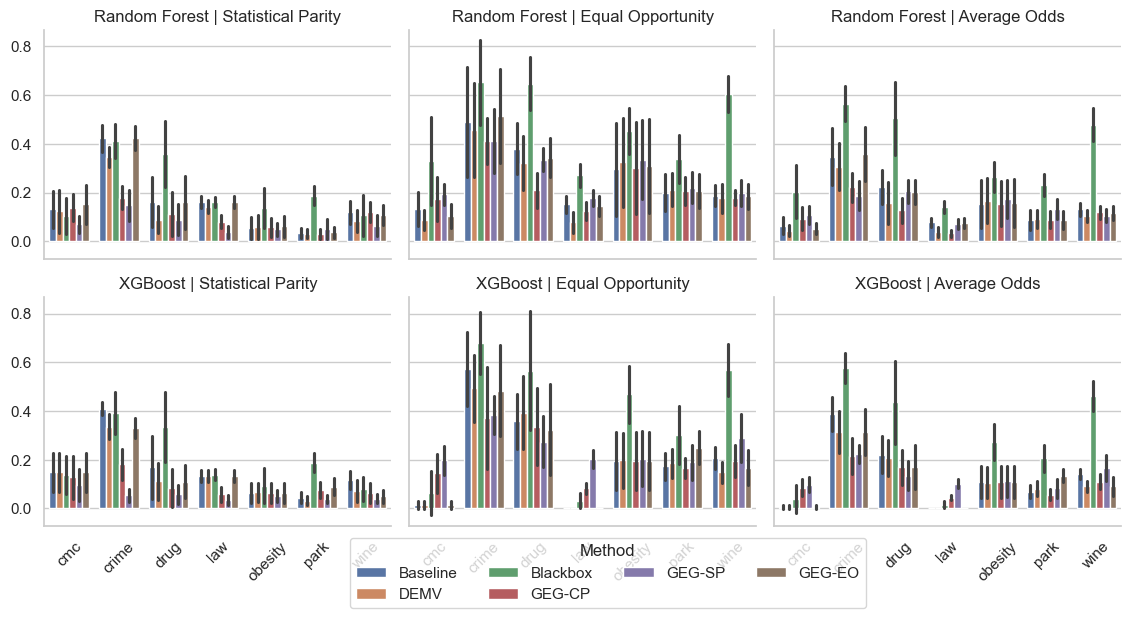

Saved rq4_fairness_comparison.pdf


In [10]:
plot_fair = df_all.melt(
    id_vars=["dataset", "model", "method"],
    value_vars=FAIRNESS_METRICS,
    var_name="metric",
    value_name="value",
)
plot_fair["metric"] = plot_fair["metric"].map(METRIC_LABELS)
plot_fair["model"]  = plot_fair["model"].map(MODEL_LABELS)
plot_fair["method"] = pd.Categorical(plot_fair["method"], categories=METHODS_ORDER, ordered=True)

g = sns.FacetGrid(
    plot_fair,
    row="model",
    col="metric",
    height=3,
    aspect=1.3,
    row_order=[MODEL_LABELS[m] for m in MODELS],
)
g.map_dataframe(
    sns.barplot,
    x="dataset", y="value", hue="method",
    palette=PALETTE,
    hue_order=METHODS_ORDER,
    errorbar="sd",
)
g.add_legend(title="Method")
g.set_titles(row_template="{row_name}", col_template="{col_name}")
g.set_axis_labels("", "")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)
sns.move_legend(g, "lower center", ncol=4, title="Method", bbox_to_anchor=(0.5, -0.04), frameon=True)
plt.savefig(IMGS / "rq4_fairness_comparison.pdf", bbox_inches="tight")
plt.show()
print("Saved rq4_fairness_comparison.pdf")

## 8. Visualizzazione della Performance per Classificatore e Metodo

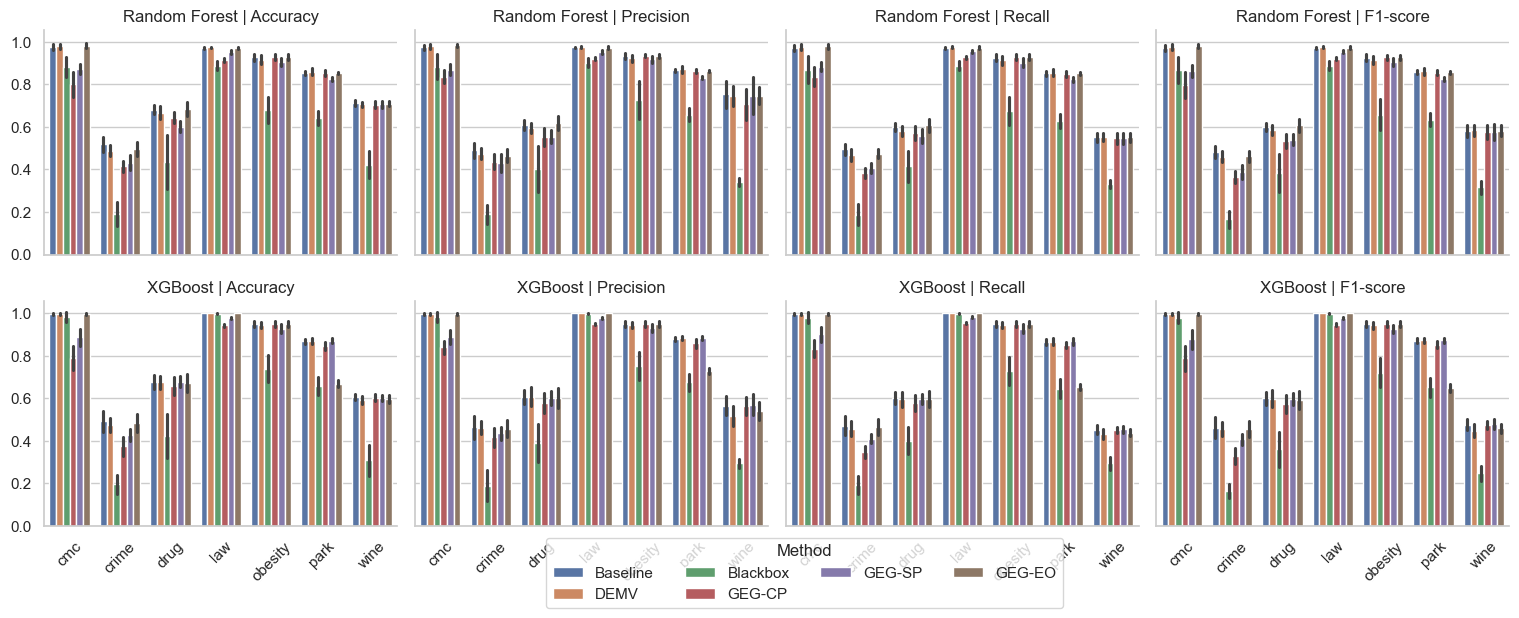

Saved rq4_performance_comparison.pdf


In [11]:
plot_perf = df_all.melt(
    id_vars=["dataset", "model", "method"],
    value_vars=PERFORMANCE_METRICS,
    var_name="metric",
    value_name="value",
)
plot_perf["metric"] = plot_perf["metric"].map(METRIC_LABELS)
plot_perf["model"]  = plot_perf["model"].map(MODEL_LABELS)
plot_perf["method"] = pd.Categorical(plot_perf["method"], categories=METHODS_ORDER, ordered=True)

g = sns.FacetGrid(
    plot_perf,
    row="model",
    col="metric",
    height=3,
    aspect=1.3,
    row_order=[MODEL_LABELS[m] for m in MODELS],
)
g.map_dataframe(
    sns.barplot,
    x="dataset", y="value", hue="method",
    palette=PALETTE,
    hue_order=METHODS_ORDER,
    errorbar="sd",
)
g.add_legend(title="Method")
g.set_titles(row_template="{row_name}", col_template="{col_name}")
g.set_axis_labels("", "")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)
sns.move_legend(g, "lower center", ncol=4, title="Method", bbox_to_anchor=(0.5, -0.04), frameon=True)
plt.savefig(IMGS / "rq4_performance_comparison.pdf", bbox_inches="tight")
plt.show()
print("Saved rq4_performance_comparison.pdf")

## 9. Analisi del Trade-off Fairness–Performance

Indice composito per ogni classificatore:

$$T(\alpha) = \alpha \cdot \text{F1} + (1 - \alpha) \cdot (1 - \bar{\text{Fair}})$$

dove $\bar{\text{Fair}} = \frac{|SP| + |EO| + |AO|}{3}$.  
$\alpha \in [0,1]$ bilancia performance e fairness. Un punto di intersezione $\alpha^*$ indica il valore soglia oltre cui GEG supera il baseline in termini di indice composito.

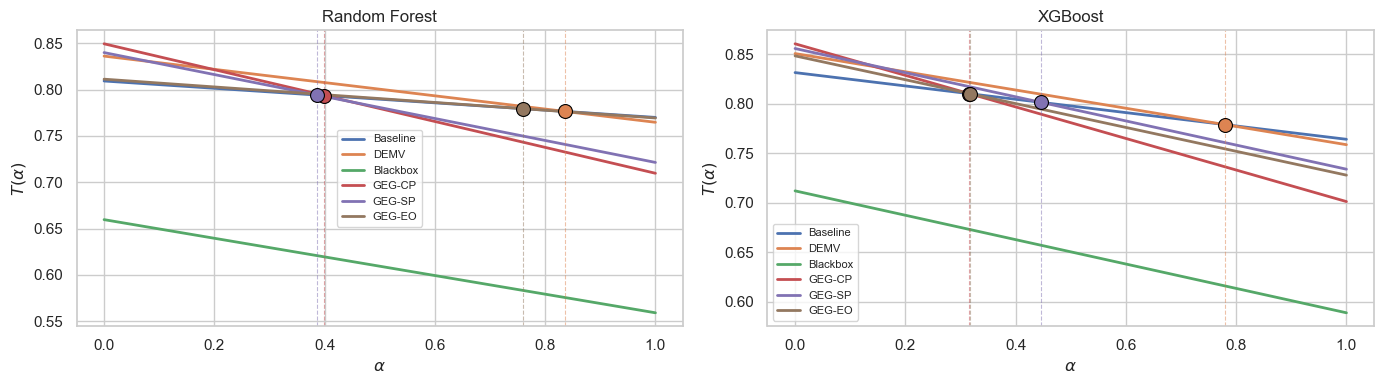

Saved rq4_tradeoff_alpha.pdf

Global means per model:


accuracy  f1_score  fair_mean
model method                                 
rf    Baseline    0.8052    0.7700     0.1907
      DEMV        0.7981    0.7648     0.1638
      Blackbox    0.5914    0.5591     0.3403
      GEG-CP      0.7511    0.7097     0.1505
      GEG-SP      0.7558    0.7214     0.1600
      GEG-EO      0.8032    0.7694     0.1887
xgb   Baseline    0.7978    0.7640     0.1687
      DEMV        0.7933    0.7585     0.1494
      Blackbox    0.6145    0.5887     0.2881
      GEG-CP      0.7373    0.7010     0.1396
      GEG-SP      0.7669    0.7337     0.1443
      GEG-EO      0.7667    0.7277     0.1518

In [12]:
# Global means per (model, method), averaged over all datasets and folds
global_means = (
    df_all.groupby(["model", "method"])[FAIRNESS_METRICS + PERFORMANCE_METRICS]
    .mean()
    .reset_index()
)
global_means["fair_mean"] = global_means[FAIRNESS_METRICS].mean(axis=1)
global_means["method"] = pd.Categorical(global_means["method"], categories=METHODS_ORDER, ordered=True)
# This trade-off plot compares only Baseline vs GEG variants; drop methods
# outside METHODS_ORDER (DEMV/Blackbox become NaN under the categorical cast).
global_means = global_means.dropna(subset=["method"]).sort_values(["model", "method"])

alphas = np.linspace(0, 1, 101)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

for ax, model in zip(axes, MODELS):
    gm_model = global_means[global_means["model"] == model]
    method_scores = {}
    for _, row in gm_model.iterrows():
        perf = row["f1_score"]
        fair = row["fair_mean"]
        scores = alphas * perf + (1 - alphas) * (1 - fair)
        method_scores[row["method"]] = (perf, fair, scores)
        ax.plot(alphas, scores, label=row["method"], color=PALETTE[METHODS_ORDER.index(row["method"])], lw=2)

    # Mark intersections with Baseline
    if "Baseline" in method_scores:
        base_perf, base_fair, _ = method_scores["Baseline"]
        for method in [m for m in METHODS_ORDER if m != "Baseline"]:
            if method not in method_scores:
                continue
            m_perf, m_fair, _ = method_scores[method]
            denom = (base_perf - m_perf) + (base_fair - m_fair)
            if abs(denom) < 1e-12:
                continue
            alpha_star = (base_fair - m_fair) / denom
            if 0 <= alpha_star <= 1:
                score_star = alpha_star * base_perf + (1 - alpha_star) * (1 - base_fair)
                ax.scatter(alpha_star, score_star, color=PALETTE[METHODS_ORDER.index(method)],
                           s=100, zorder=6, edgecolors="black", linewidths=0.8)
                ax.axvline(alpha_star, color=PALETTE[METHODS_ORDER.index(method)], lw=0.8, linestyle="--", alpha=0.5)

    ax.set_title(MODEL_LABELS[model])
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(r"$T(\alpha)$")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(IMGS / "rq4_tradeoff_alpha.pdf", bbox_inches="tight")
plt.show()
print("Saved rq4_tradeoff_alpha.pdf")

print("\nGlobal means per model:")
display(global_means[["model", "method", "accuracy", "f1_score", "fair_mean"]]
        .sort_values(["model", "method"])
        .set_index(["model", "method"]))

## 10. Grafico di Pareto: Trade-off Fairness–Performance per Dataset

Scatter plot (fairness, F1) per ciascuna combinazione (dataset, method).  
Layout: **righe** = classificatore (RF, XGBoost) · **colonne** = dataset (7).  
I punti sul **fronte di Pareto** (nessun altro punto domina su entrambi gli assi) sono evidenziati con una stella.  
Il fronte di Pareto è calcolato su tutti i metodi del rispettivo (model, dataset).

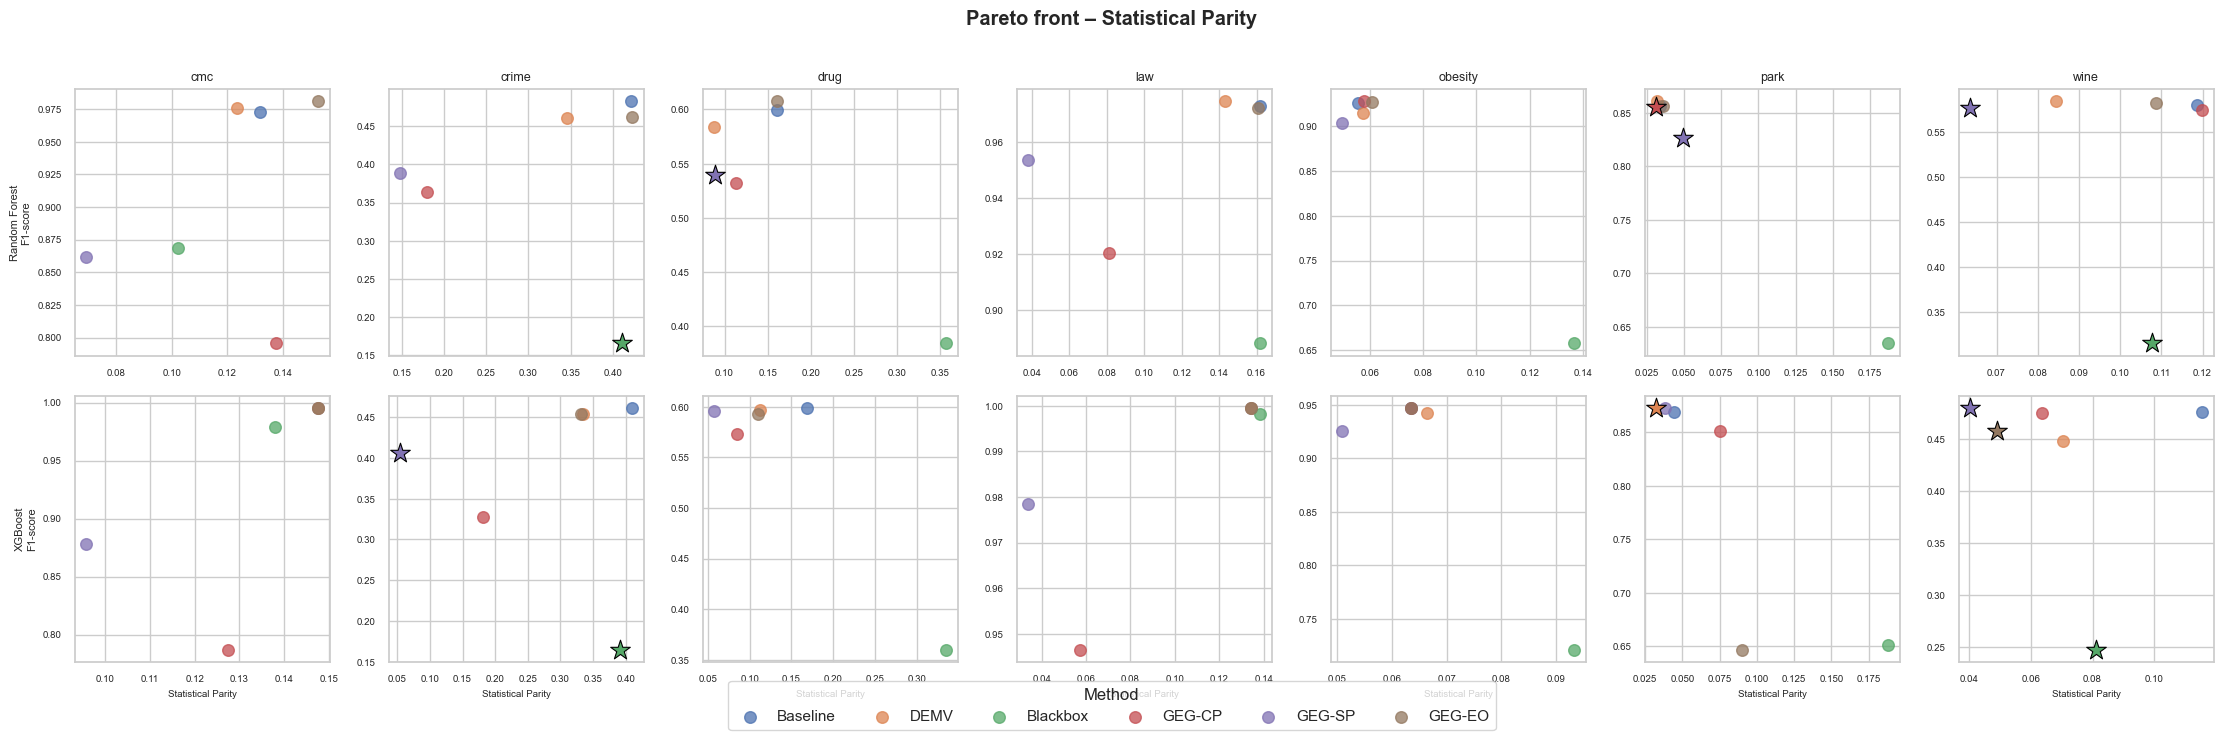

Saved rq4_pareto_sp_per_dataset.pdf


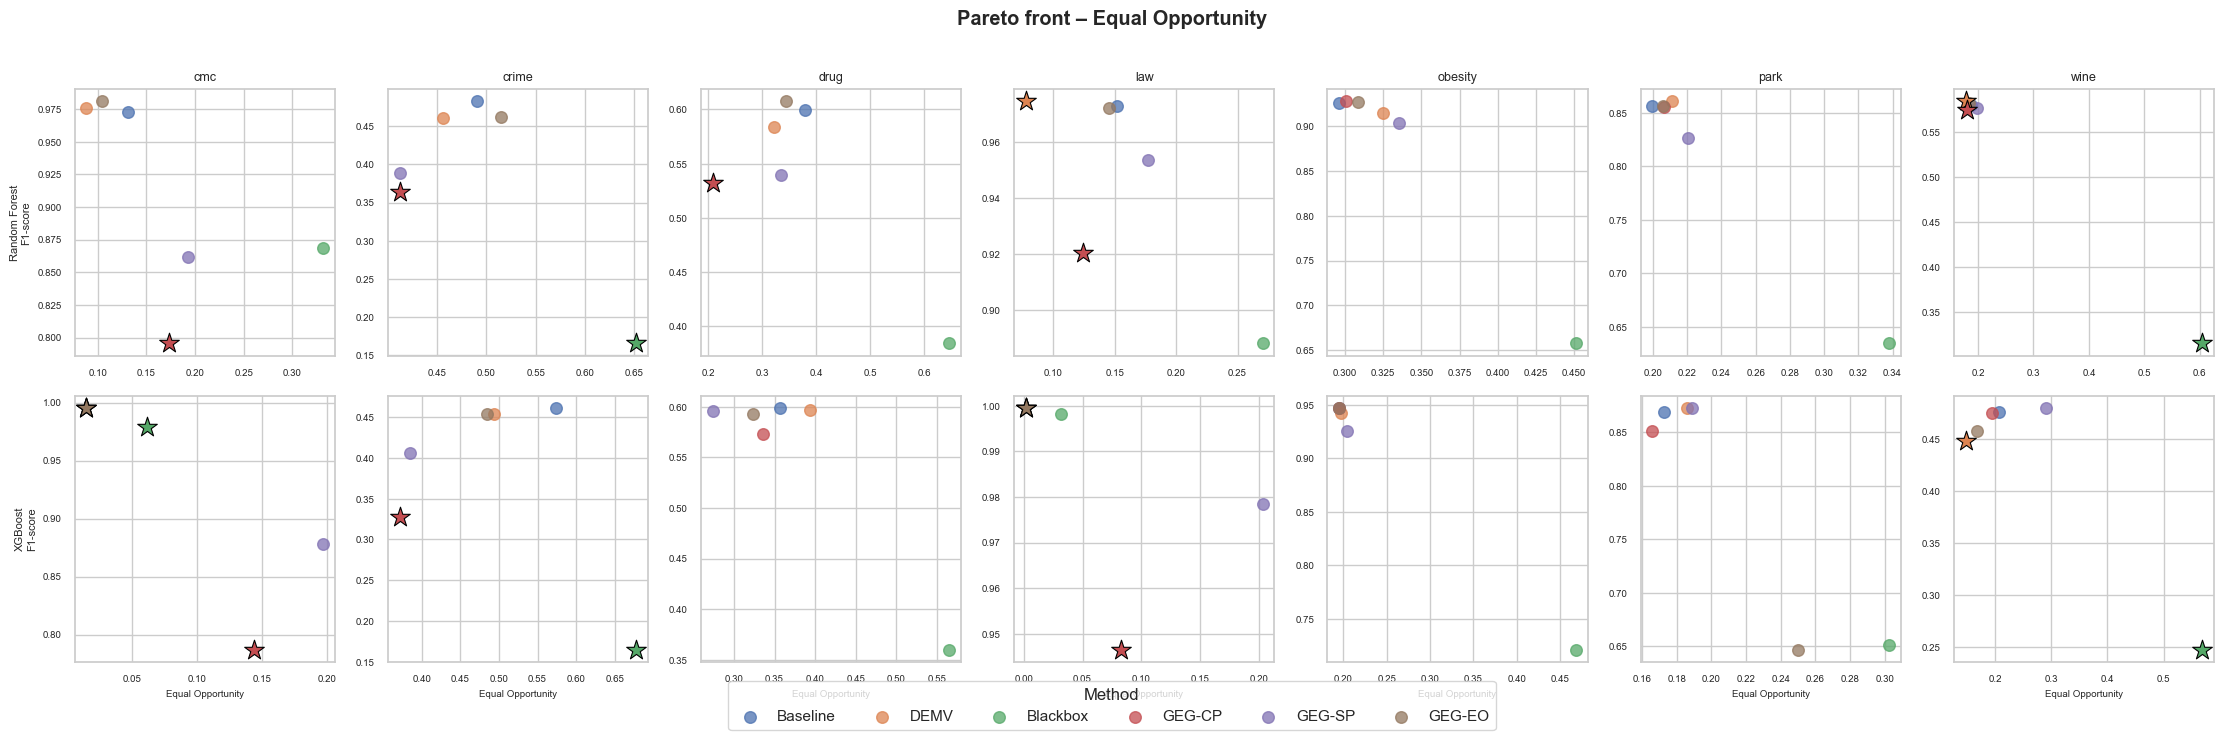

Saved rq4_pareto_eo_per_dataset.pdf


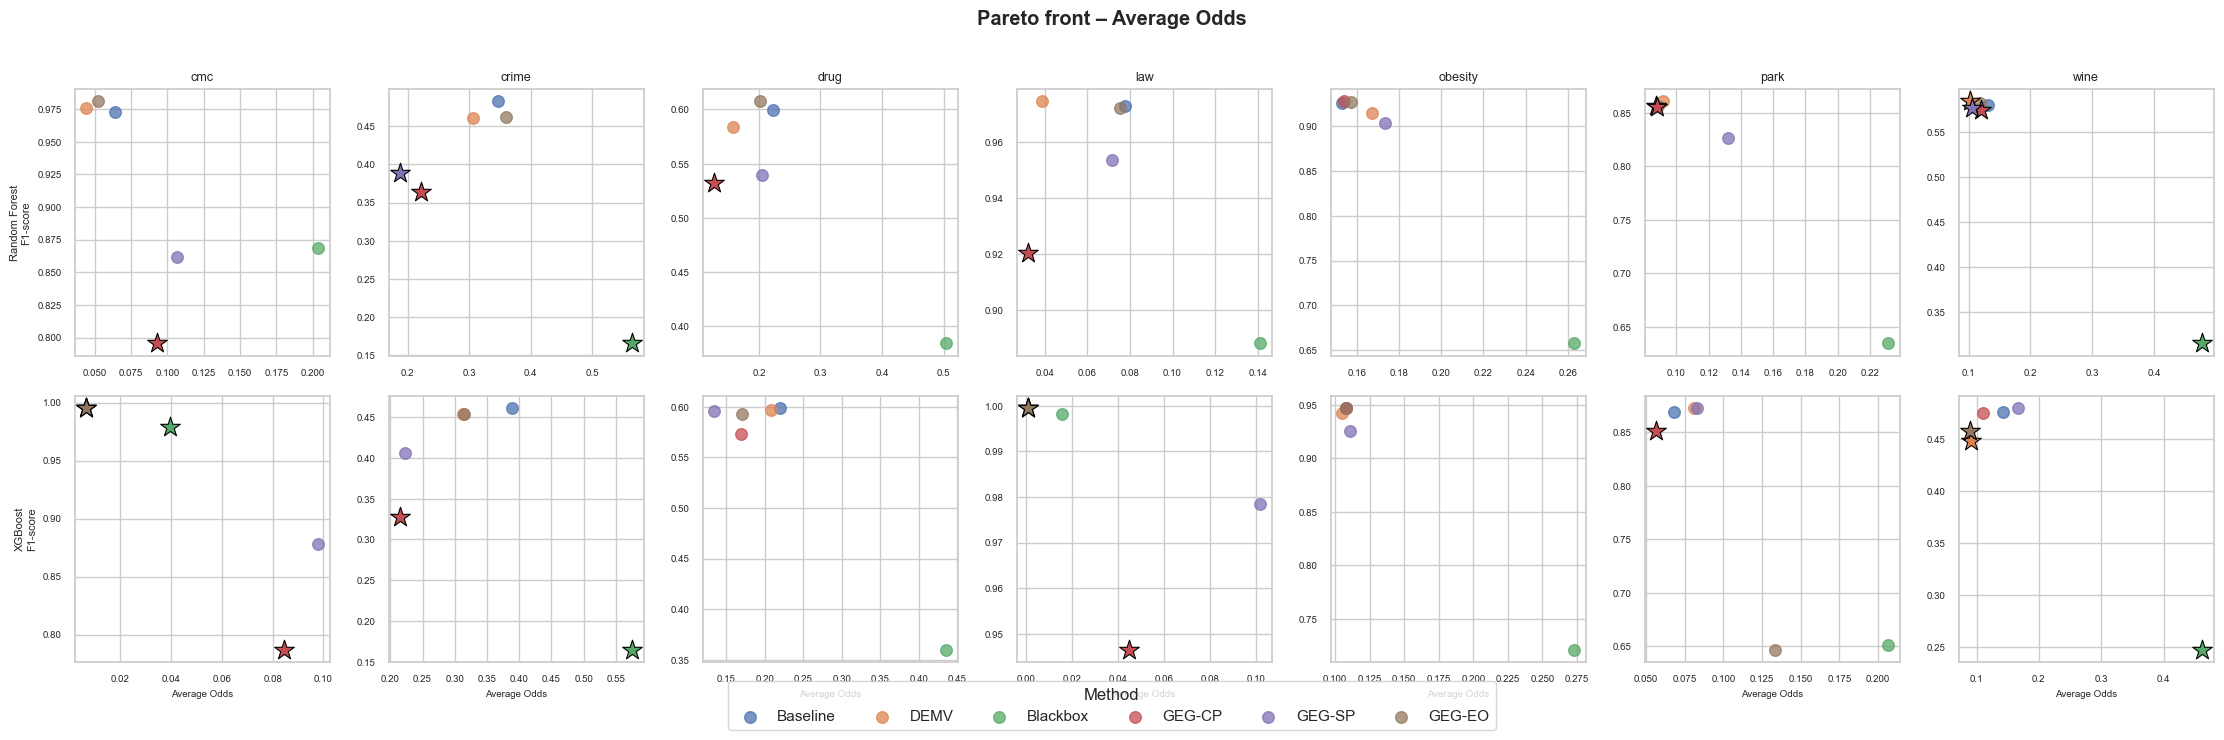

Saved rq4_pareto_ao_per_dataset.pdf


In [13]:
def is_pareto_efficient(costs):
    """Return boolean mask of Pareto-efficient points.
    costs[:,0]: fairness (minimise), costs[:,1]: F1 (maximise → pass as negative).
    """
    n = len(costs)
    dominated = np.zeros(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            if costs[j, 0] <= costs[i, 0] and costs[j, 1] >= costs[i, 1]:
                if costs[j, 0] < costs[i, 0] or costs[j, 1] > costs[i, 1]:
                    dominated[i] = True
                    break
    return ~dominated


scatter_data = combined[[
    "dataset", "model", "method",
    "wc_statistical_parity_mean", "wc_equal_opportunity_mean",
    "wc_average_odds_mean", "f1_score_mean",
]].copy()
scatter_data["fair_mean"] = scatter_data[[
    "wc_statistical_parity_mean", "wc_equal_opportunity_mean", "wc_average_odds_mean"
]].mean(axis=1)

nrows = len(MODELS)      # 2  (rf, xgb)
ncols = len(DATASETS)    # 7

for fairness_col, fair_label, fname in [
    ("wc_statistical_parity_mean", "Statistical Parity", "rq4_pareto_sp_per_dataset.pdf"),
    ("wc_equal_opportunity_mean",  "Equal Opportunity",  "rq4_pareto_eo_per_dataset.pdf"),
    ("wc_average_odds_mean",       "Average Odds",       "rq4_pareto_ao_per_dataset.pdf"),
]:
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.2 * ncols, 3.5 * nrows),
        sharex=False, sharey=False,
    )

    for row_idx, model in enumerate(MODELS):
        # Compute Pareto mask across all (dataset × method) points for this model
        sd_model = scatter_data[scatter_data["model"] == model].copy().reset_index(drop=True)
        costs_all = sd_model[[fairness_col, "f1_score_mean"]].values.copy()
        costs_all[:, 1] = -costs_all[:, 1]
        pareto_mask = is_pareto_efficient(costs_all)

        for col_idx, ds in enumerate(DATASETS):
            ax = axes[row_idx, col_idx]
            ds_mask = sd_model["dataset"] == ds
            ds_data = sd_model[ds_mask].reset_index(drop=True)
            ds_pareto = pareto_mask[ds_mask.values]

            for method in METHODS_ORDER:
                m_mask = ds_data["method"] == method
                subset = ds_data[m_mask]
                par_sub = ds_pareto[m_mask.values]
                color = PALETTE[METHODS_ORDER.index(method)]

                non_par = subset[~par_sub]
                ax.scatter(
                    non_par[fairness_col], non_par["f1_score_mean"],
                    color=color, alpha=0.75, s=70, label=method,
                )
                par = subset[par_sub]
                ax.scatter(
                    par[fairness_col], par["f1_score_mean"],
                    color=color, marker="*", s=220,
                    edgecolors="black", linewidths=0.8, zorder=5,
                )

            # Title: dataset name on top row, model label on left column
            title = ds if row_idx == 0 else ""
            if title:
                ax.set_title(title, fontsize=9)
            if col_idx == 0:
                ax.set_ylabel(f"{MODEL_LABELS[model]}\nF1-score", fontsize=8)
            else:
                ax.set_ylabel("")
            if row_idx == nrows - 1:
                ax.set_xlabel(fair_label, fontsize=7)
            else:
                ax.set_xlabel("")
            ax.tick_params(labelsize=7)

    # Shared legend from the last axes
    handles, labels_leg = axes[0, 0].get_legend_handles_labels()
    seen = set()
    unique = [(h, l) for h, l in zip(handles, labels_leg)
              if l not in seen and not seen.add(l)]
    fig.legend(
        [h for h, _ in unique], [l for _, l in unique],
        loc="lower center", ncol=len(METHODS_ORDER),
        title="Method", bbox_to_anchor=(0.5, -0.03), frameon=True,
    )
    plt.suptitle(f"Pareto front – {fair_label}", fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(IMGS / fname, bbox_inches="tight")
    plt.show()
    print(f"Saved {fname}")

## 11. Heatmap di Pareto-ottimalità

Per ogni combinazione **(modello, dataset, metrica di fairness)** si calcola il fronte di Pareto
nello spazio bidimensionale **(F1-score, metrica di fairness)** considerando tutti i metodi
(Baseline, DEMV, Blackbox, GEG-CP, GEG-SP, GEG-EO). Un metodo è *Pareto-ottimale* se nessun altro
metodo lo domina (≥ F1 **e** ≤ fairness, con almeno una disuguaglianza stretta).

La heatmap conta, per ciascun metodo, **quante volte compare sul fronte di Pareto** considerando
tutte le combinazioni di F1 con le tre metriche di fairness (SP, EO, AO). Una heatmap per
classificatore; ogni cella ha valore massimo pari al numero di dataset (7). La colonna **Total**
somma sulle tre metriche di fairness (massimo 21).

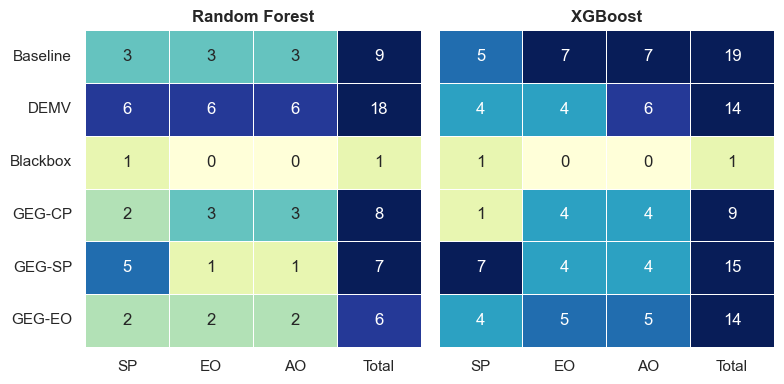

Saved rq4_pareto_heatmap.pdf

Pareto-front appearances aggregated over classifiers:


,SP,EO,AO,Total
Baseline,8,10,10,28
DEMV,10,10,12,32
Blackbox,2,0,0,2
GEG-CP,3,7,7,17
GEG-SP,12,5,5,22
GEG-EO,6,7,7,20


In [18]:
# Pareto-optimality heatmap: count how often each method lands on the Pareto front
# across every (model, dataset, fairness-metric) combination, pairing F1 with each
# fairness metric (SP, EO, AO). Recomputed straight from df_all so DEMV/Blackbox are
# included (they are dropped by the METHODS_ORDER categorical used in `combined`).

ALL_METHODS = ["Baseline", "DEMV", "Blackbox", "GEG-CP", "GEG-SP", "GEG-EO"]
FAIR_PAIRS = [
    ("wc_statistical_parity", "SP"),
    ("wc_equal_opportunity",  "EO"),
    ("wc_average_odds",       "AO"),
]

# Mean over the 10 folds per (dataset, model, method)
mean_df = (
    df_all.groupby(["dataset", "model", "method"])[FAIRNESS_METRICS + PERFORMANCE_METRICS]
    .mean()
    .reset_index()
)


def pareto_optimal_2d(fair, f1):
    """Boolean mask of Pareto-optimal points: minimise `fair`, maximise `f1`."""
    fair = np.asarray(fair, dtype=float)
    f1 = np.asarray(f1, dtype=float)
    n = len(fair)
    optimal = np.ones(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            if (fair[j] <= fair[i] and f1[j] >= f1[i]
                    and (fair[j] < fair[i] or f1[j] > f1[i])):
                optimal[i] = False
                break
    return optimal


# counts[model]: DataFrame (methods x fairness metrics) of Pareto-front appearances
counts = {
    model: pd.DataFrame(0, index=ALL_METHODS, columns=[lbl for _, lbl in FAIR_PAIRS])
    for model in MODELS
}

for model in MODELS:
    for ds in DATASETS:
        sub = (
            mean_df[(mean_df["model"] == model) & (mean_df["dataset"] == ds)]
            .set_index("method")
            .reindex(ALL_METHODS)
            .dropna(subset=["f1_score"])
        )
        if sub.empty:
            continue
        for fcol, lbl in FAIR_PAIRS:
            mask = pareto_optimal_2d(sub[fcol].values, sub["f1_score"].values)
            for method in sub.index[mask]:
                counts[model].loc[method, lbl] += 1

# Plot one annotated heatmap per classifier, with a Total column across fairness metrics
fig, axes = plt.subplots(1, len(MODELS), figsize=(8.0, 4))
if len(MODELS) == 1:
    axes = [axes]

vmax = max(c.values.max() for c in counts.values())
for ax, model in zip(axes, MODELS):
    heat = counts[model].copy()
    heat["Total"] = heat.sum(axis=1)
    sns.heatmap(
        heat,
        annot=True, fmt="d", cmap="YlGnBu",
        vmin=0, vmax=len(DATASETS),
        linewidths=0.5, linecolor="white",
        ax=ax,
        cbar=False
        
    )
    # De-emphasise the Total column scale (it can exceed len(DATASETS))
    ax.set_title(MODEL_LABELS[model], fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="y", rotation=0)
    if model == "xgb":
        ax.set_yticklabels("", rotation=0)

# plt.suptitle(
#     "Pareto-optimality count (F1 vs fairness) per method",
#     fontweight="bold", y=1.03,
# )
plt.tight_layout()
plt.savefig(IMGS / "rq4_pareto_heatmap.pdf", bbox_inches="tight")
plt.show()
print("Saved rq4_pareto_heatmap.pdf")

# Aggregate across both classifiers (Total appearances over all model x dataset x fairness)
agg = sum(counts.values())
agg["Total"] = agg.sum(axis=1)
print("\nPareto-front appearances aggregated over classifiers:")
display(agg)

## Harmonic Mean: Trade-off Fairness–Performance

In [45]:
from scipy.stats import hmean

df_all.head()
df_all['harmonic_mean'] = df_all.apply(
    lambda row: hmean([row['accuracy'], row['f1_score'], 1 - row['wc_statistical_parity'], 1 - row['wc_equal_opportunity'], 1 - row['wc_average_odds']]),
    axis=1)

In [46]:
rf_data = df_all[df_all['model'] == 'rf']

In [47]:
rf_data

,fold,accuracy,precision,recall,f1_score,statistical_parity,equal_opportunity,average_odds,wc_statistical_parity,wc_equal_opportunity,wc_average_odds,constraint,dataset,model,method,harmonic_mean
0,1,0.9797,0.9760,0.9808,0.9782,0.0289,-0.1429,-0.0766,0.0289,0.1429,0.0766,rf,cmc,rf,Baseline,0.9394
1,2,0.9797,0.9797,0.9760,0.9778,0.1967,0.0769,0.0333,0.1967,0.0769,0.0333,rf,cmc,rf,Baseline,0.9249
2,3,0.9797,0.9838,0.9714,0.9771,0.1452,-0.0994,-0.0497,0.1452,0.0994,0.0497,rf,cmc,rf,Baseline,0.9299
3,4,0.9728,0.9762,0.9712,0.9729,0.1392,0.0645,0.0323,0.1392,0.0645,0.0323,rf,cmc,rf,Baseline,0.9399
4,5,0.9728,0.9649,0.9622,0.9635,0.1293,-0.2857,-0.1520,0.1293,0.2857,0.1520,rf,cmc,rf,Baseline,0.8630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
825,6,0.7232,0.7185,0.5559,0.5766,-0.0514,-0.0097,-0.0006,0.0514,0.1667,0.0844,eo,wine,rf,GEG-EO,0.7736
826,7,0.6971,0.7056,0.5188,0.5467,-0.0775,-0.0818,-0.1008,0.0775,0.1669,0.1442,eo,wine,rf,GEG-EO,0.7444
827,8,0.7212,0.7469,0.5770,0.6153,-0.0620,-0.0330,-0.0268,0.0620,0.2000,0.1011,eo,wine,rf,GEG-EO,0.7763
828,9,0.6987,0.8005,0.5310,0.5634,-0.1473,-0.1681,-0.1155,0.1473,0.1681,0.1155,eo,wine,rf,GEG-EO,0.7450


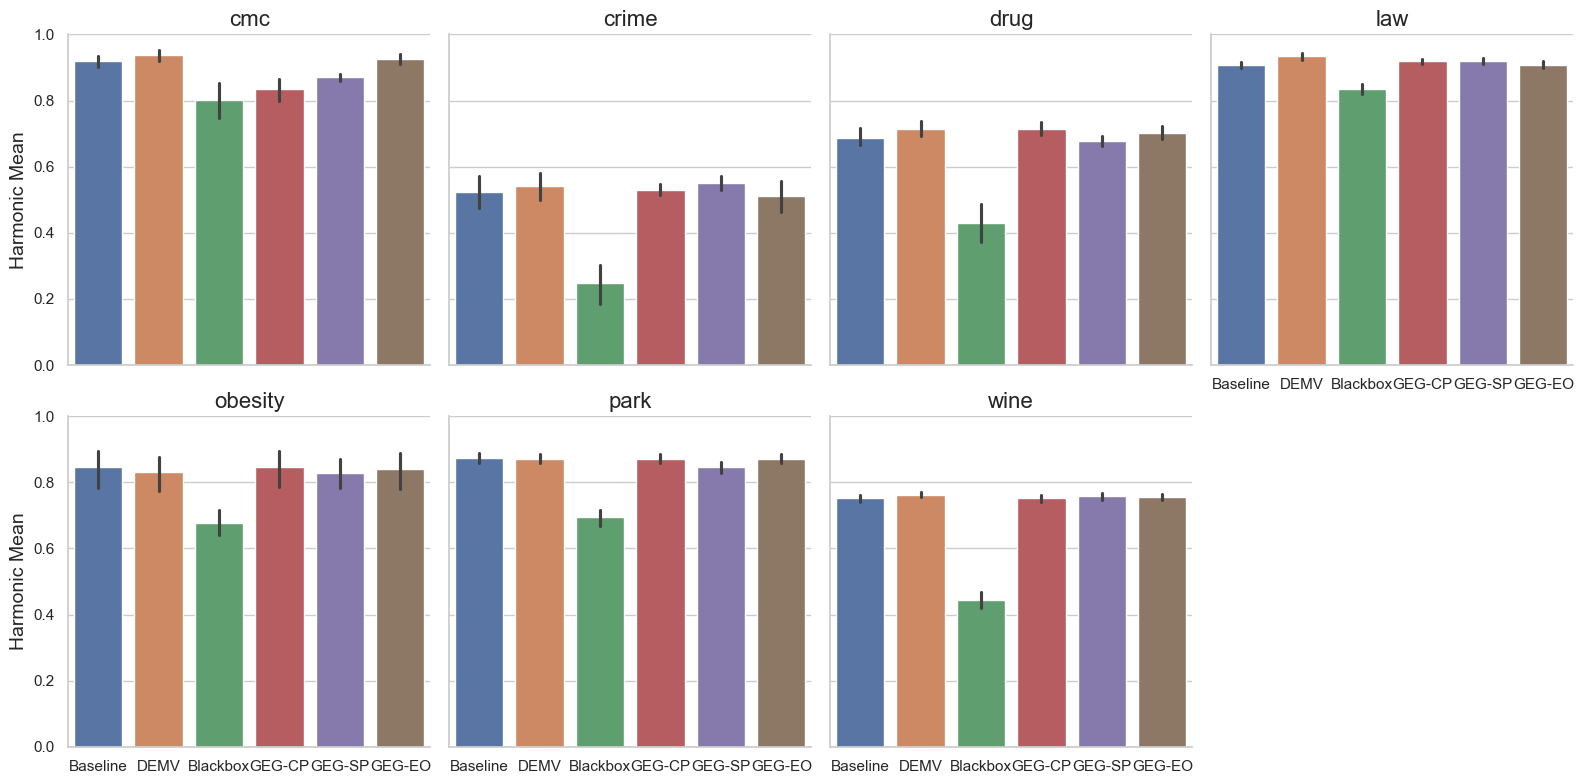

In [48]:
g = sns.FacetGrid(rf_data, col="dataset", col_wrap=4, height=4)
g.map_dataframe(
    sns.barplot,
    y="harmonic_mean",
    x="method",
    hue="method",
    palette=sns.color_palette(n_colors=len(METHOD_LABELS)),
)
g.set_axis_labels("", "Harmonic Mean", size=14)
g.set_titles(col_template="{col_name}", size=16)
plt.tight_layout()
plt.savefig(IMGS / "rq4_harmonic_mean_rf.pdf", bbox_inches="tight")
plt.show()

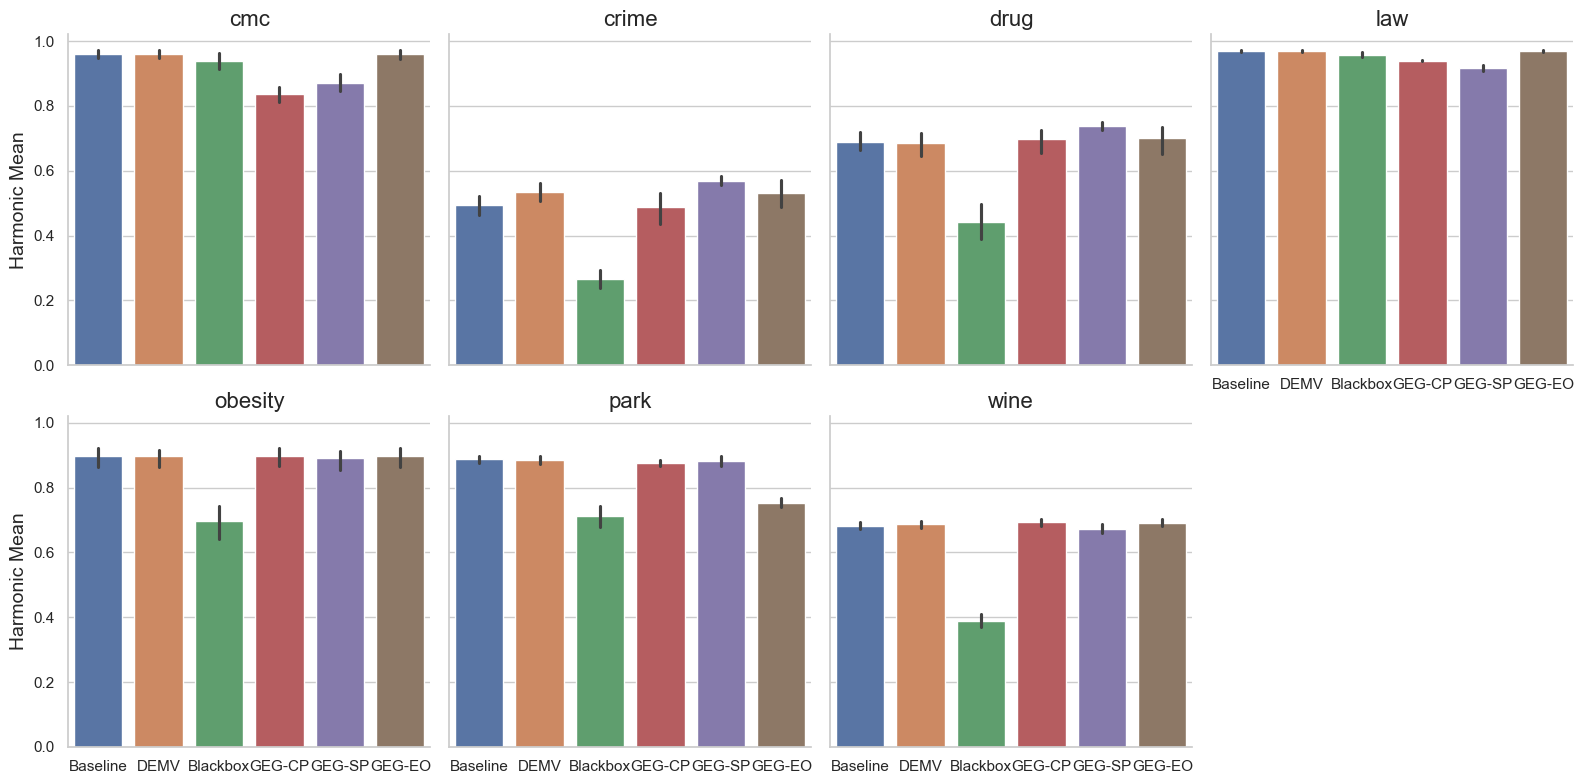

In [49]:
xgb_data = df_all[df_all['model'] == 'xgb']
g = sns.FacetGrid(xgb_data, col="dataset", col_wrap=4, height=4)
g.map_dataframe(
    sns.barplot, y="harmonic_mean", x="method", hue="method", palette=sns.color_palette(n_colors=len(METHOD_LABELS))
)
g.set_axis_labels("", "Harmonic Mean", size=14)
g.set_titles(col_template="{col_name}", size=16)
plt.tight_layout()
plt.savefig(IMGS / "rq4_harmonic_mean_xgb.pdf", bbox_inches="tight")
plt.show()